error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


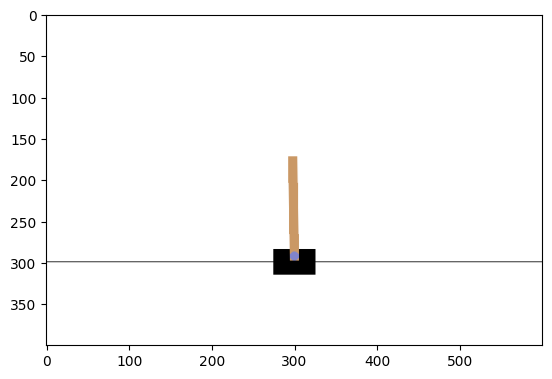

In [1]:
import sys, os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Создаём среду
env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape
img = env.render()
plt.imshow(img)
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    def __init__(self, state_dim, n_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim[0], 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, n_actions)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)  

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = DQN(state_dim, n_actions).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

In [4]:
def get_action(state, epsilon=0):
    """
    примеры действий с эпсилон-жадной политикой
    Резюме: с p = epsilon выберите случайное действие, иначе выберите действие с наибольшим Q
    (s, a)
    """
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)  # (1, state_dim)
        with torch.no_grad():
            q_values = network(state_t).cpu().numpy()[0]
        return np.argmax(q_values)

In [5]:
test_state, _ = env.reset()
test_tensor = torch.FloatTensor(test_state).unsqueeze(0).to(device)
test_output = network(test_tensor)
assert test_output.shape == (1, n_actions), "пожалуйста, убедитесь, что ваша модель \
отображает состояние s -> [Q(s,a0),..., Q(s, a_last)]"
assert not hasattr(network.fc3, 'activation') or network.fc3.activation is None, "пожалуйста, убедитесь, что вы \
предсказываете q-значения без нелинейности"

# проверка эпсилон-жадной стратегии
s, _ = env.reset()
assert np.shape(get_action(s)) == (), "верните только одно действие (integer)"

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for _ in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed' % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [6]:
gamma = 0.99

def generate_session(env, t_max=1000, epsilon=0, train=False):
    """
    играть с env с приблизительным агентом q-обучения и одновременно тренировать его.
    """
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            a_t = torch.LongTensor([a]).to(device)
            r_t = torch.FloatTensor([r]).to(device)
            next_s_t = torch.FloatTensor(next_s).unsqueeze(0).to(device) if not done else None
            done_t = torch.BoolTensor([done]).to(device)
            q_sa = network(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
            if not done:
                with torch.no_grad():
                    next_q = network(next_s_t)
                    max_next_q = next_q.max(dim=1)[0]
                target = r_t + gamma * max_next_q
            else:
                target = r_t

            loss = loss_fn(q_sa, target.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_reward += r
        s = next_s
        if done:
            break
    return total_reward

In [7]:
epsilon = 0.5
for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    print("epoch #{}:\tmean reward = {:.3f}\tepsilon = {:.3f}".format(i, np.mean(session_rewards), epsilon))
    epsilon *= 0.99
    assert epsilon >= 1e-4, "Убедитесь, что эпсилон всегда отличен от нуля во время обучения"
    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0:	mean reward = 13.580	epsilon = 0.500
epoch #1:	mean reward = 13.060	epsilon = 0.495
epoch #2:	mean reward = 13.590	epsilon = 0.490
epoch #3:	mean reward = 14.500	epsilon = 0.485
epoch #4:	mean reward = 13.230	epsilon = 0.480
epoch #5:	mean reward = 15.670	epsilon = 0.475
epoch #6:	mean reward = 13.470	epsilon = 0.471
epoch #7:	mean reward = 20.970	epsilon = 0.466
epoch #8:	mean reward = 21.250	epsilon = 0.461
epoch #9:	mean reward = 32.990	epsilon = 0.457
epoch #10:	mean reward = 38.740	epsilon = 0.452
epoch #11:	mean reward = 35.020	epsilon = 0.448
epoch #12:	mean reward = 40.010	epsilon = 0.443
epoch #13:	mean reward = 50.670	epsilon = 0.439
epoch #14:	mean reward = 49.450	epsilon = 0.434
epoch #15:	mean reward = 54.600	epsilon = 0.430
epoch #16:	mean reward = 59.680	epsilon = 0.426
epoch #17:	mean reward = 64.300	epsilon = 0.421
epoch #18:	mean reward = 78.400	epsilon = 0.417
epoch #19:	mean reward = 119.260	epsilon = 0.413
epoch #20:	mean reward = 148.230	epsilon = 0.409
